<a href="https://colab.research.google.com/github/Gautamkhushboo/Machine-Vision-LAB/blob/main/practical_1(MV_25).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

Saving Screenshot 2026-06-22 150232.png to Screenshot 2026-06-22 150232.png


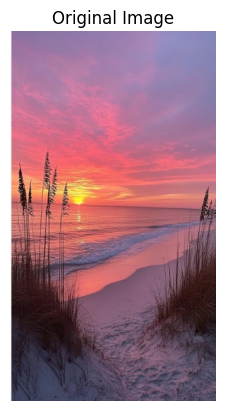

In [2]:
uploaded = files.upload()

# Load image
img_path = list(uploaded.keys())[0]
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title("Original Image")
plt.axis("off")
plt.show()

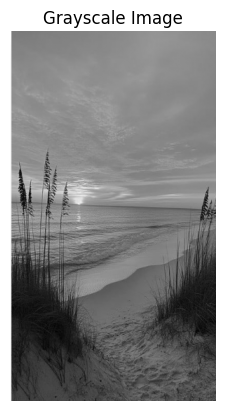

In [3]:
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

plt.imshow(gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

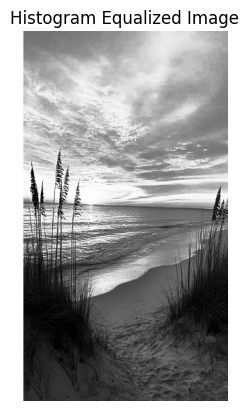

In [4]:
hist_eq = cv2.equalizeHist(gray)

plt.imshow(hist_eq, cmap='gray')
plt.title("Histogram Equalized Image")
plt.axis("off")
plt.show()

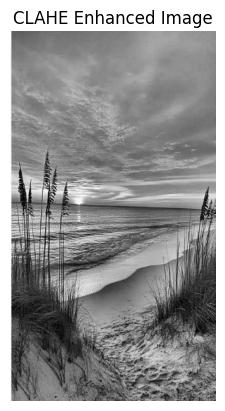

In [5]:
clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8,8))
clahe_img = clahe.apply(gray)

plt.imshow(clahe_img, cmap='gray')
plt.title("CLAHE Enhanced Image")
plt.axis("off")
plt.show()

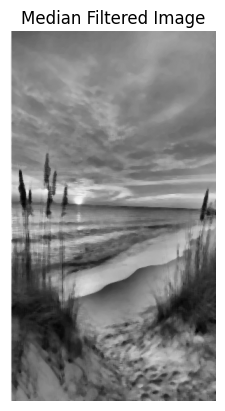

In [6]:
median = cv2.medianBlur(clahe_img, 5)

plt.imshow(median, cmap='gray')
plt.title("Median Filtered Image")
plt.axis("off")
plt.show()

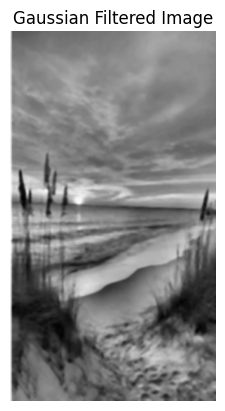

In [8]:
gauss = cv2.GaussianBlur(median, (5,5), 0)

plt.imshow(gauss, cmap='gray')
plt.title("Gaussian Filtered Image")
plt.axis("off")
plt.show()

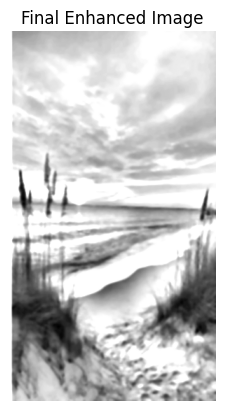

In [9]:
alpha = 1.5   # contrast
beta = 20     # brightness

enhanced = cv2.convertScaleAbs(gauss, alpha=alpha, beta=beta)

plt.imshow(enhanced, cmap='gray')
plt.title("Final Enhanced Image")
plt.axis("off")
plt.show()

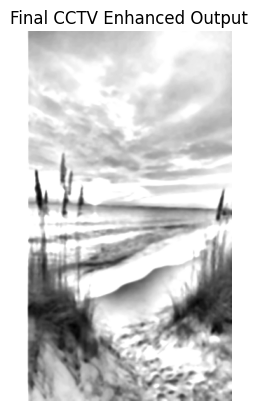

In [10]:
def enhance_cctv(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8,8))
    eq = clahe.apply(gray)

    denoise = cv2.medianBlur(eq, 5)
    smooth = cv2.GaussianBlur(denoise, (5,5), 0)

    final = cv2.convertScaleAbs(smooth, alpha=1.5, beta=20)

    return final

result = enhance_cctv(img)

plt.imshow(result, cmap='gray')
plt.title("Final CCTV Enhanced Output")
plt.axis("off")
plt.show()